Correcting the bubble charts

### Imports 

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd

from src.visualization import plot_chord

COLOR_BUTTER = "#023E8A"
COLOR_MILK = "#5A189A"

In [2]:
df = pd.read_csv("../data/bubble_chart_data.csv")

### 18

Method 1: bar chart

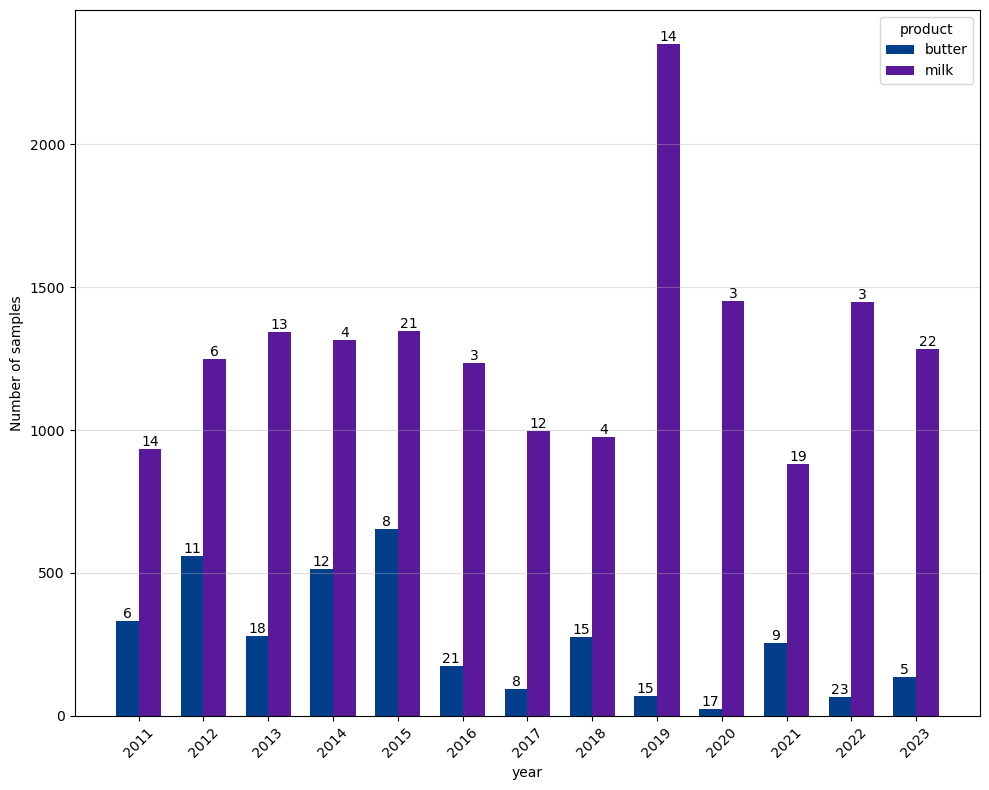

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

pivot = df.pivot(
    index="year", columns="product", values="samples_count"
).sort_index()
years = pivot.index.tolist()
x = list(range(len(years)))
width = 0.35

ax.bar(
    [xi - width / 2 for xi in x],
    pivot["butter"],
    width,
    label="butter",
    color=COLOR_BUTTER,
)
ax.bar(
    [xi + width / 2 for xi in x],
    pivot["milk"],
    width,
    label="milk",
    color=COLOR_MILK,
)

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)


df_sorted = df.sort_values(["year", "product"])
for bar, count in zip(ax.patches, df_sorted["countries_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.grid(axis="y", alpha=0.4)
ax.set_title("")
ax.set_xlabel("year")
ax.set_ylabel("Number of samples")
ax.legend(title="product")
plt.tight_layout()